# 2. Clustering

## Setup

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import cm

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import silhouette_samples

# Display numbers
pd.options.display.float_format = '{:20.2f}'.format

# Show all columns
pd.set_option('display.max_columns', None)

## Feature Engineering

#### **Load data**

In [76]:
df = pd.read_csv('../datasets/01_rfm_df.csv')

In [77]:
# Selecting columns for analysis
df = df[['CustomerID', 'Monetary', 'Frequency', 'Recency']]
df.head()

,CustomerID,Monetary,Frequency,Recency
0,12347,4310.00,7,2
1,12348,1462.20,4,75
2,12349,1457.55,1,18
3,12350,294.40,1,310
4,12352,1385.74,7,36


#### **Outlier Treatment**

##### Distribution Visualization

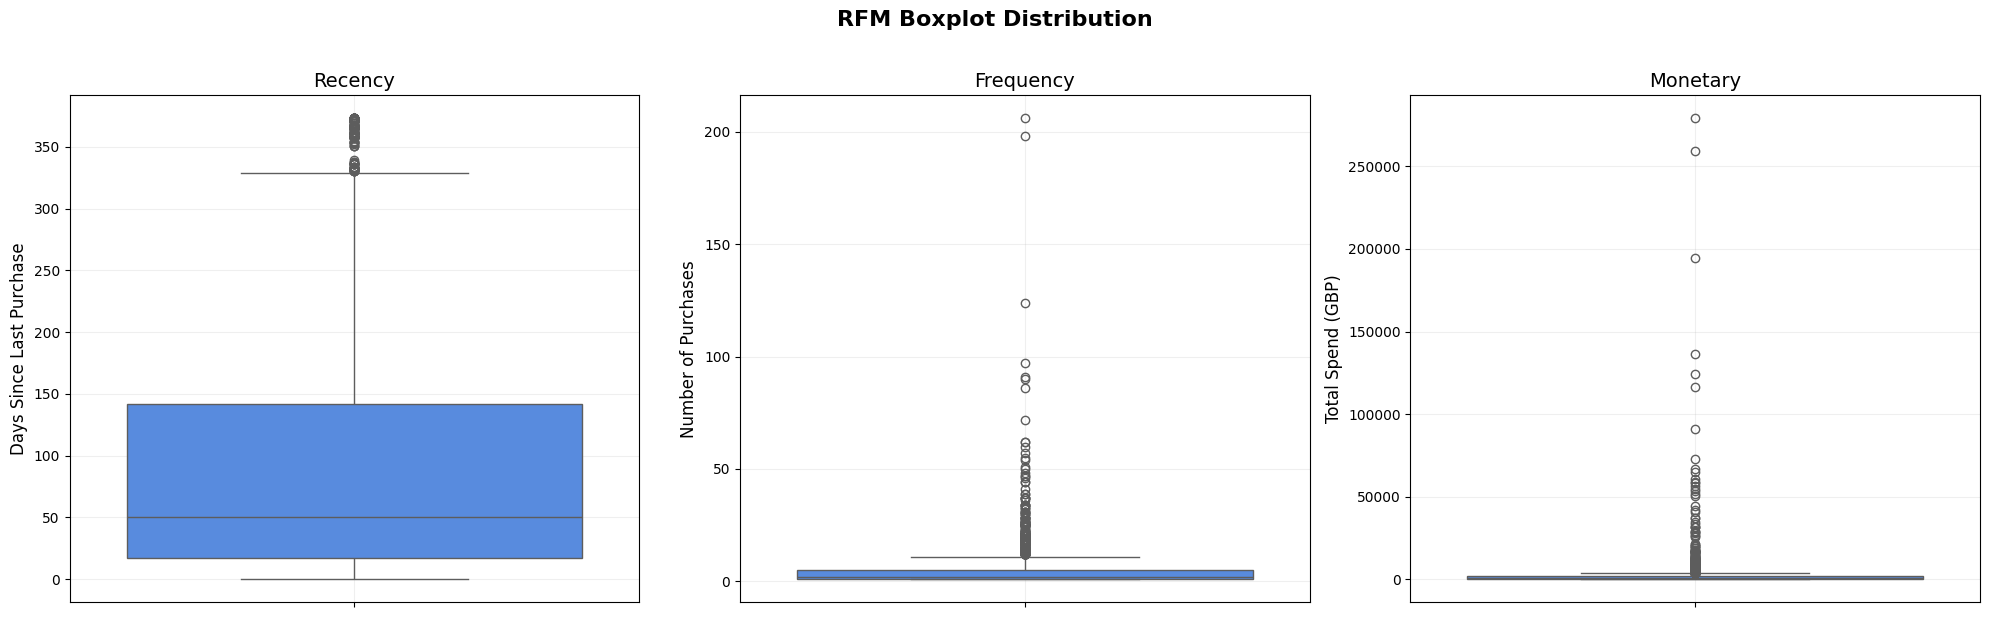

In [78]:
# Boxplot to check RFM distributions

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Create boxplot
sns.boxplot(df['Recency'], ax=ax1, color="#4285F4")
ax1.set_title('Recency',fontsize=14)
ax1.set_ylabel('Days Since Last Purchase', fontsize=12)
ax1.grid(True, alpha=0.2, linestyle='-')

sns.boxplot(df['Frequency'], ax=ax2, color="#4285F4")
ax2.set_title('Frequency',fontsize=14)
ax2.set_ylabel('Number of Purchases', fontsize=12)
ax2.grid(True, alpha=0.2, linestyle='-')

sns.boxplot(df['Monetary'], ax=ax3, color="#4285F4")
ax3.set_title('Monetary',fontsize=14)
ax3.set_ylabel('Total Spend (GBP)', fontsize=12)
ax3.grid(True, alpha=0.2, linestyle='-')

plt.suptitle('RFM Boxplot Distribution',fontsize=16, fontweight='bold',y=1.02)

plt.tight_layout()
plt.show()

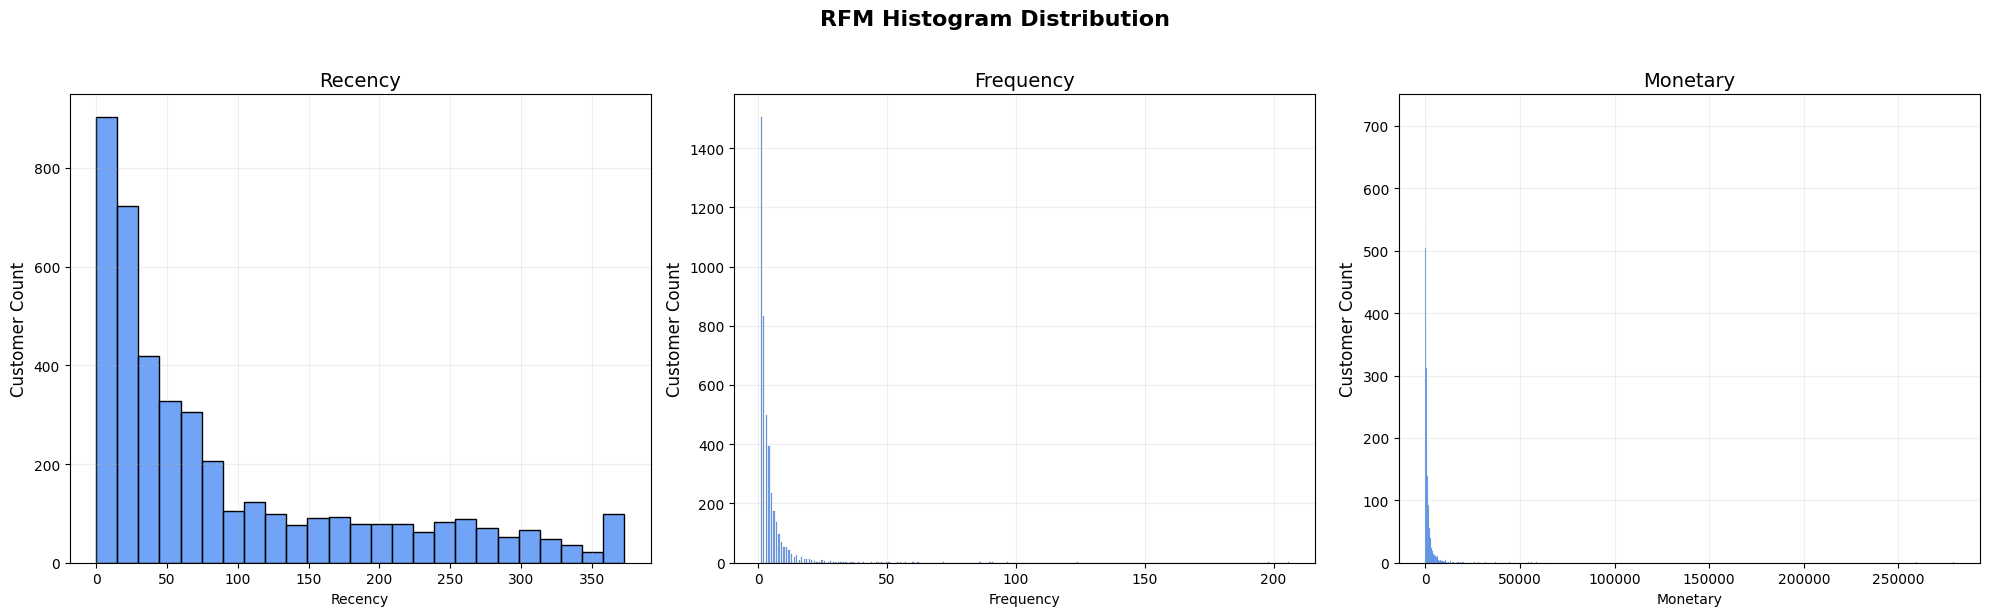

In [79]:
# Histogram to check RFM distributions

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Create boxplot
sns.histplot(df['Recency'], ax=ax1, color="#4285F4")
ax1.set_title('Recency',fontsize=14)
ax1.set_ylabel('Customer Count', fontsize=12)
ax1.grid(True, alpha=0.2, linestyle='-')

sns.histplot(df['Frequency'], ax=ax2, color="#4285F4")
ax2.set_title('Frequency',fontsize=14)
ax2.set_ylabel('Customer Count', fontsize=12)
ax2.grid(True, alpha=0.2, linestyle='-')

sns.histplot(df['Monetary'], ax=ax3, color="#4285F4")
ax3.set_title('Monetary',fontsize=14)
ax3.set_ylabel('Customer Count', fontsize=12)
ax3.grid(True, alpha=0.2, linestyle='-')

plt.suptitle('RFM Histogram Distribution',fontsize=16, fontweight='bold',y=1.02)

plt.tight_layout()
plt.show()

The dataset is highly skewed, with frequency and monetary containing extreme values.  
Recency is more balanced, with just a few outliers — normal for this kind of transactional data.  

Outlier treatment will be applied only to frequency and monetary (upper bound).  
Recency needs no treatment, and neither does the lower bound of frequency or monetary, since no outliers were found there.

##### Interquartile Range (IQR) Outlier

In [80]:
# The approach was adapted from a Kaggle example and applied to the IQR treatment.
# Calculate Q1 and Q3 for each column
Q1_f = df['Frequency'].quantile(0.25)
Q3_f = df['Frequency'].quantile(0.75)

Q1_m = df['Monetary'].quantile(0.25)
Q3_m = df['Monetary'].quantile(0.75)

# Compute IQR
IQR_f = Q3_f - Q1_f
IQR_m = Q3_m - Q1_m

# Outlier threshold
upper_bound_f = Q3_f + 1.5 * IQR_f
upper_bound_m = Q3_m + 1.5 * IQR_m

# Find outliers
outliers = df[
    (df['Frequency'] > upper_bound_f) |
    (df['Monetary'] > upper_bound_m)
]

print('Total outliers count:', len(outliers))

# Removing outliers from dataset
df_IQR = df[
    ~(
      (df['Frequency'] > upper_bound_f) |
      (df['Monetary'] > upper_bound_m)
     )
]

print(f'Rows before: {len(df)}\nRows after: {len(df_IQR)}')

Total outliers count: 469
Rows before: 4333
Rows after: 3864


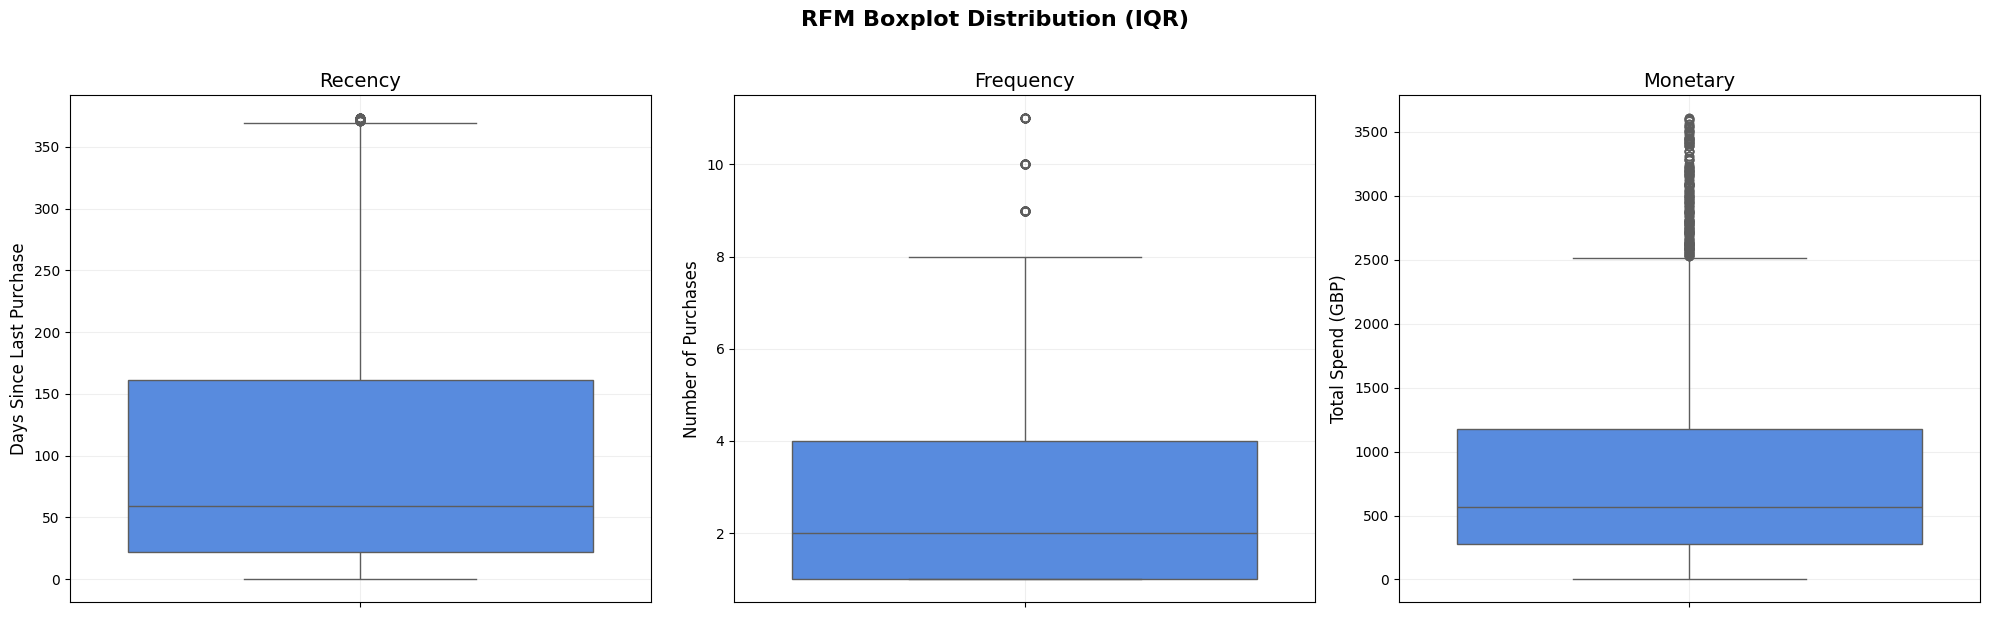

In [81]:
# Boxplot to check RFM distributions

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Create boxplot
sns.boxplot(df_IQR['Recency'], ax=ax1, color="#4285F4")
ax1.set_title('Recency',fontsize=14)
ax1.set_ylabel('Days Since Last Purchase', fontsize=12)
ax1.grid(True, alpha=0.2, linestyle='-')

sns.boxplot(df_IQR['Frequency'], ax=ax2, color="#4285F4")
ax2.set_title('Frequency',fontsize=14)
ax2.set_ylabel('Number of Purchases', fontsize=12)
ax2.grid(True, alpha=0.2, linestyle='-')

sns.boxplot(df_IQR['Monetary'], ax=ax3, color="#4285F4")
ax3.set_title('Monetary',fontsize=14)
ax3.set_ylabel('Total Spend (GBP)', fontsize=12)
ax3.grid(True, alpha=0.2, linestyle='-')

plt.suptitle('RFM Boxplot Distribution (IQR)',fontsize=16, fontweight='bold',y=1.02)

plt.tight_layout()
plt.show()

In [82]:
# Reseting index
df_IQR = df_IQR.reset_index(drop=True)

The distribution is more balanced, making the boxplot easier to interpret and allowing a clearer view of the median, outliers, and IQR.    
The IQR method provides a robust way to identify outliers, and the resulting distribution is noticeably cleaner.     
However, around 11% of the data was removed.    
This is a relatively high proportion and may exclude some observations that are unusual but still valid for this type of data.

##### Winsorization & Trimming

Techniques used to handle extreme outliers using specified percentile thresholds. Winsorization replaces extreme values, while trimming removes them.

In [83]:
# Checking upper percentiles for extreme values
for column in ['Frequency', 'Monetary']:
    print(f'\n{column}:')
    for percentile in [0.90, 0.95, 0.99]:
        value = df[column].quantile(percentile)
        print(f'{percentile:.0%} percentile: {value:.2f}')


Frequency:
90% percentile: 9.00
95% percentile: 13.00
99% percentile: 30.00

Monetary:
90% percentile: 3546.12
95% percentile: 5710.91
99% percentile: 17356.08


Looking at the boxplot, histogram, and percentile results together, values between the 90th and 95th percentiles appear to be potential outliers, but they are not extreme.     
The much longer right tail is driven by a small number of observations beyond the 99th percentile.

In [84]:
# Count values above the 99th percentile
freq_99 = df[df['Frequency'] > df['Frequency'].quantile(0.99)]
mon_99 = df[df['Monetary'] > df['Monetary'].quantile(0.99)]

print('Customers above the 99th percentile in Frequency:', len(freq_99))
print('Customers above the 99th percentile in Monetary:', len(mon_99))

Customers above the 99th percentile in Frequency: 42
Customers above the 99th percentile in Monetary: 44


In [85]:
# The trimming approach was adapted from a Kaggle example and applied to the 99th-percentile thresholds identified above.
# Trim observations above the 99th percentile
df_trim = df[
    ~(
      (df['Frequency'] > df['Frequency'].quantile(.99)) |   
      (df['Monetary'] > df['Monetary'].quantile(.99))
      )
]

print(f'Rows before: {len(df)}')
print(f'Rows after: {len(df_trim)}')

Rows before: 4333
Rows after: 4270


Applying the 99th-percentile thresholds removed 63 customers in total. Of these, approximately 23 were above the threshold for both Frequency and Monetary,    
while the remaining observations exceeded the threshold for only one of the two variables.

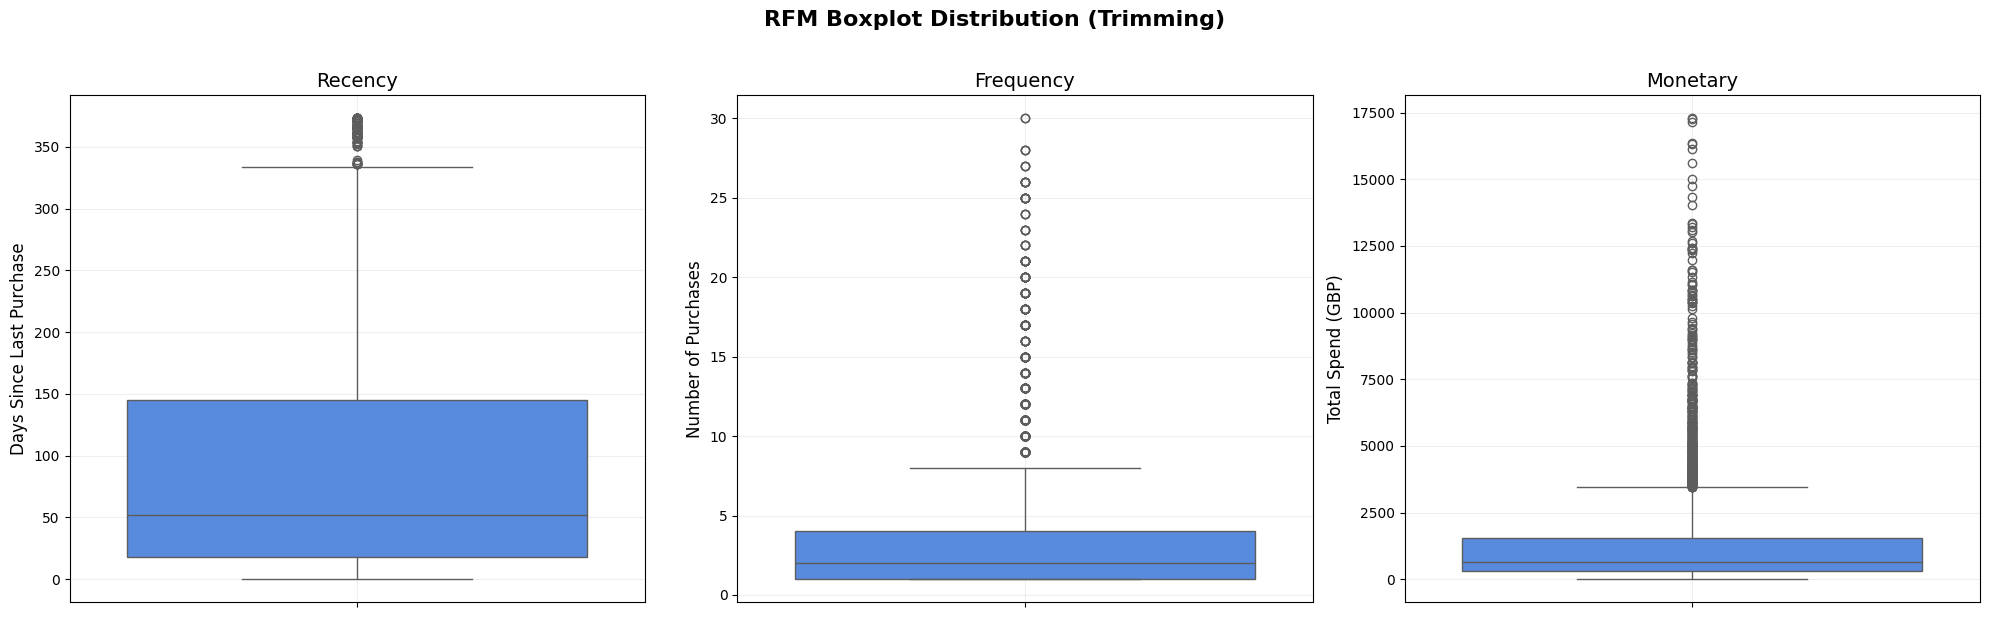

In [86]:
# Boxplot to check RFM distributions

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Create boxplot
sns.boxplot(df_trim['Recency'], ax=ax1, color="#4285F4")
ax1.set_title('Recency',fontsize=14)
ax1.set_ylabel('Days Since Last Purchase', fontsize=12)
ax1.grid(True, alpha=0.2, linestyle='-')

sns.boxplot(df_trim['Frequency'], ax=ax2, color="#4285F4")
ax2.set_title('Frequency',fontsize=14)
ax2.set_ylabel('Number of Purchases', fontsize=12)
ax2.grid(True, alpha=0.2, linestyle='-')

sns.boxplot(df_trim['Monetary'], ax=ax3, color="#4285F4")
ax3.set_title('Monetary',fontsize=14)
ax3.set_ylabel('Total Spend (GBP)', fontsize=12)
ax3.grid(True, alpha=0.2, linestyle='-')

plt.suptitle('RFM Boxplot Distribution (Trimming)',fontsize=16, fontweight='bold',y=1.02)

plt.tight_layout()
plt.show()

In [87]:
# Checking total removed customers by each method
print('Customers removed by IQR:', len(df) - len(df_IQR))
print('Customers removed by trimming:', len(df) - len(df_trim))

Customers removed by IQR: 469
Customers removed by trimming: 63


In [88]:
# Reseting index
df_trim = df_trim.reset_index(drop=True)

#### **Scaling**
MinMaxScaler and RobustScaler will be applied to the RFM variables to compare different combinations of outlier treatment and scaling methods for the clustering analysis.

##### RobustScaler

In [89]:
# RobustScaler inicialization
scaler_rob = RobustScaler()

In [90]:
# Robust scaling on raw data
df_robust = pd.DataFrame(
    scaler_rob.fit_transform(df[['Recency', 'Frequency', 'Monetary']]),
    columns=['Recency', 'Frequency', 'Monetary']
)

print(df_robust.head(2))

               Recency            Frequency             Monetary
0                -0.38                 1.25                 2.76
1                 0.20                 0.50                 0.61


In [91]:
# Robust scaling on trimmed data
trim_robust = pd.DataFrame(
    scaler_rob.fit_transform(df_trim[['Recency', 'Frequency', 'Monetary']]),
    columns=['Recency', 'Frequency', 'Monetary']
)

print(trim_robust.head(2))

               Recency            Frequency             Monetary
0                -0.39                 1.67                 2.91
1                 0.19                 0.67                 0.65


In [92]:
# Robust scaling on IQR-treated data
IQR_robust = pd.DataFrame(
    scaler_rob.fit_transform(df_IQR[['Recency', 'Frequency', 'Monetary']]),
    columns=['Recency', 'Frequency', 'Monetary']
)

print(IQR_robust.head(2))

               Recency            Frequency             Monetary
0                 0.12                 0.67                 1.00
1                -0.29                -0.33                 1.00


##### MinMaxScaler

In [93]:
# MinMaxScaler inicialization
scaler_mm = MinMaxScaler()

In [94]:
# MinMaxScaler on raw data
df_minmax = pd.DataFrame(
    scaler_mm.fit_transform(df[['Recency', 'Frequency', 'Monetary']]),
    columns=['Recency', 'Frequency', 'Monetary']
)

print(df_minmax.head(2))

               Recency            Frequency             Monetary
0                 0.01                 0.03                 0.02
1                 0.20                 0.01                 0.01


In [95]:
# MinMaxScaler on trimmed data
trim_minmax = pd.DataFrame(
    scaler_mm.fit_transform(df_trim[['Recency', 'Frequency', 'Monetary']]),
    columns=['Recency', 'Frequency', 'Monetary']
)

print(trim_minmax.head(2))

               Recency            Frequency             Monetary
0                 0.01                 0.21                 0.25
1                 0.20                 0.10                 0.08


In [96]:
# MinMaxScaler on IQR-treated data
IQR_minmax = pd.DataFrame(
    scaler_mm.fit_transform(df_IQR[['Recency', 'Frequency', 'Monetary']]),
    columns=['Recency', 'Frequency', 'Monetary']
)

print(IQR_minmax.head(2))

               Recency            Frequency             Monetary
0                 0.20                 0.30                 0.41
1                 0.05                 0.00                 0.40


MinMaxScaler does not reduce the influence of outliers, as extreme values can affect the minimum and maximum used for scaling.     
RobustScaler is less sensitive to outliers because it uses the median and interquartile range (IQR).

The expectation is that MinMaxScaler may perform better on a dataset where extreme outliers have already been treated, such as the IQR-based dataset. RobustScaler may be more suitable for the 99th-percentile trimmed data,     
where most observations are retained while the most extreme values are removed, while having minimum effect on IQR treated dataset.    

The raw dataset will also be included to evaluate the clustering results without outlier treatment.

#### **Visualizations**

##### IQR dataset 

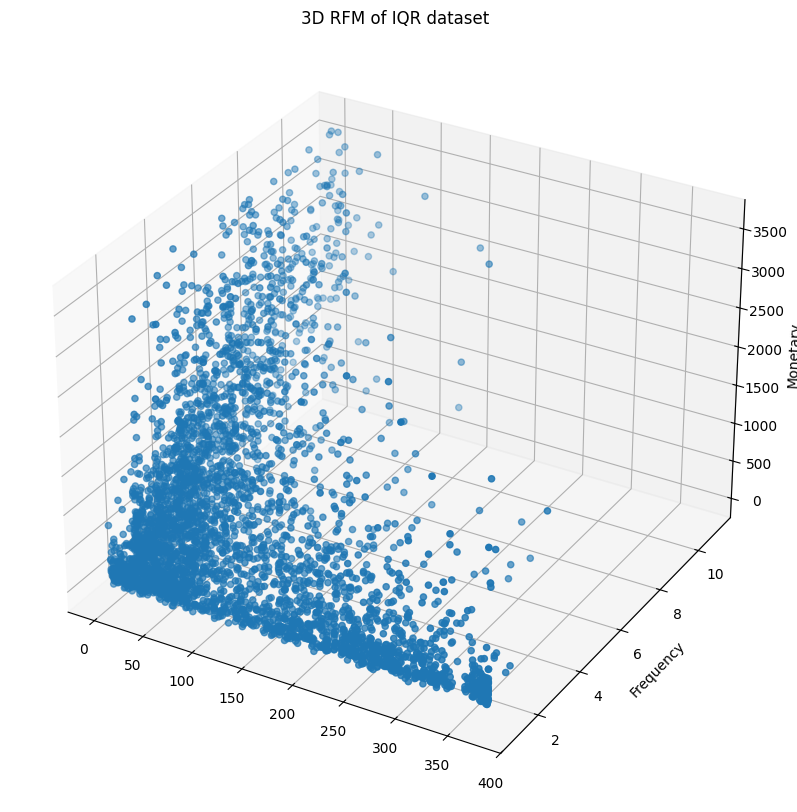

In [97]:
fig = plt.figure(figsize=(10,10))

ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(df_IQR['Recency'], df_IQR['Frequency'], df_IQR['Monetary'])

ax.set_label('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

ax.set_title('3D RFM of IQR dataset')
plt.show()

The IQR treatment reduces the influence of extreme observations and makes the main distribution more concentrated.     
However, it removes a substantial number of observations from the upper tail, potentially losing information about high-frequency and high-spending customers.

##### Trimmed dataset

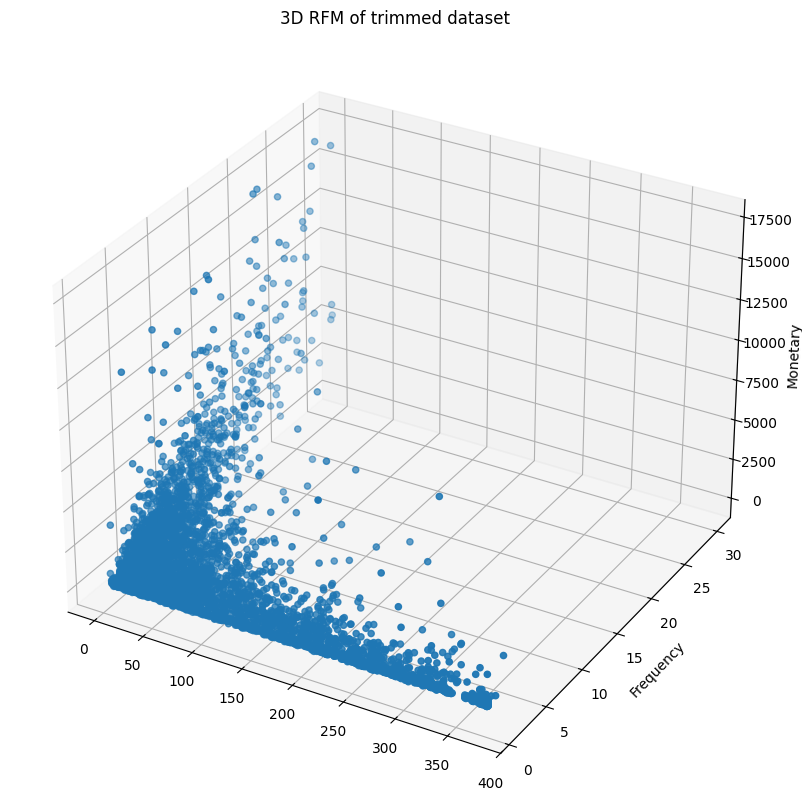

In [98]:
fig = plt.figure(figsize=(10,10))

ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(df_trim['Recency'], df_trim['Frequency'], df_trim['Monetary'])

ax.set_label('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

ax.set_title('3D RFM of trimmed dataset')
plt.show()


The 99th-percentile trimming removes only the most extreme observations while preserving the overall shape of the original distribution.    
The data remains right-skewed, but the extreme tail is reduced, providing a more representative view of the typical customer distribution.

##### Original dataset

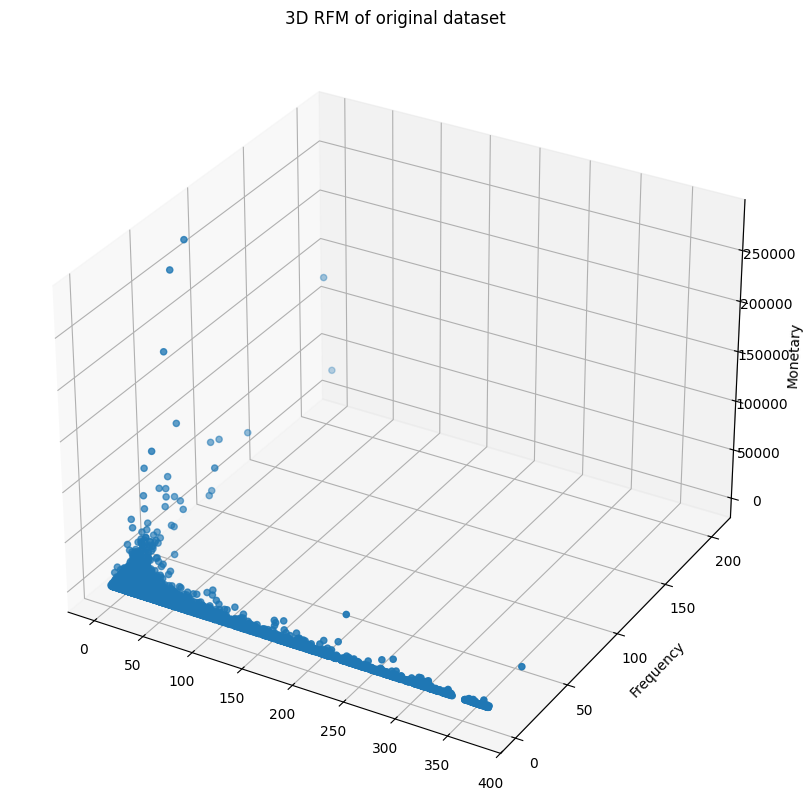

In [99]:
fig = plt.figure(figsize=(10,10))

ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(df['Recency'], df['Frequency'], df['Monetary'])

ax.set_label('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

ax.set_title('3D RFM of original dataset')
plt.show()

The original dataset shows a highly skewed distribution, with most customers concentrated in a relatively small range and a long tail of higher values. 
These extreme observations may have a strong influence on distance-based clustering.

## Modelling

#### **K-means**

**References**
- K-means application: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html     
- Elbow method and Silhouette method: https://github.com/trentpark8800/online-retail-data-clustering/blob/main/online-retail-data-clustering.ipynb

##### Raw Dataset + MinMaxScaler

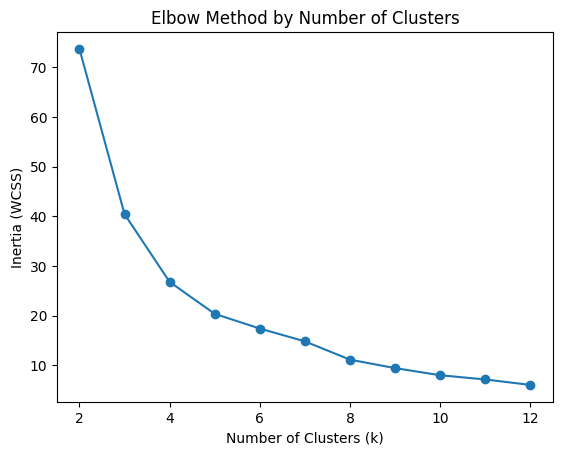

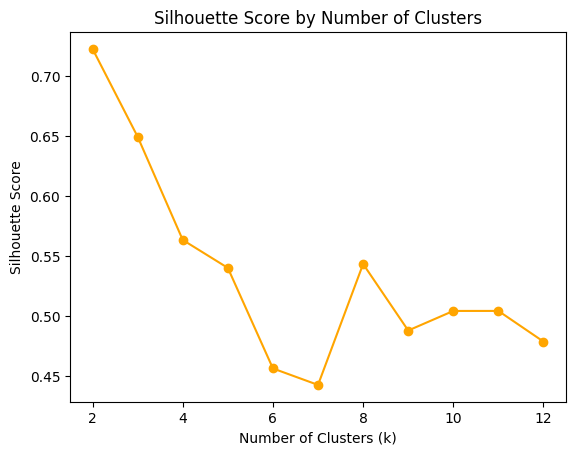

In [100]:
# Creating Elbow method and Silhouette line plot
max_k = 12

inertias = []
silhouette_scores = []
k_values = range(2, max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(df_minmax)
    sil_score = silhouette_score(df_minmax, cluster_labels)
    silhouette_scores.append(sil_score)
    inertias.append(kmeans.inertia_)

# Elbow Method
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method by Number of Clusters')
plt.show()

# Silhouette Score
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.show()

In [101]:
# Applying model
kmeans = KMeans(n_clusters=3, random_state=42)

# Fitting model
cluster_labels = kmeans.fit_predict(df_minmax)

# Checking DB index
db_df_minmax = davies_bouldin_score(df_minmax, cluster_labels)
print(f"Davies-Bouldin Index: {db_df_minmax:.3f}")

# Creating cluster labels
df_minmax['Cluster'] = cluster_labels

Davies-Bouldin Index: 0.501


In [102]:
# RFM mean values by cluster
cluster_means_minmax = df_minmax.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Percentage of customers by cluster
cluster_distribution_minmax = df_minmax['Cluster'].value_counts(normalize=True) * 100

print('CLUSTER DISTRIBUTION (PERCENTAGE)')
print('='*50)
print(cluster_distribution_minmax)
print('='*50)
print('CLUSTER MEAN')
print('='*50)
print(cluster_means_minmax)


CLUSTER DISTRIBUTION (PERCENTAGE)
Cluster
0                  67.57
2                  18.28
1                  14.15
Name: proportion, dtype: float64
CLUSTER MEAN
                     Recency            Frequency             Monetary
Cluster                                                               
0                       0.09                 0.02                 0.01
1                       0.79                 0.00                 0.00
2                       0.42                 0.01                 0.00


<Axes: xlabel='Cluster'>

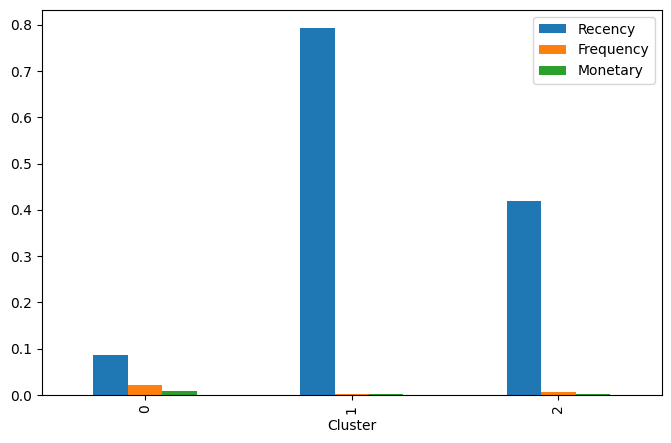

In [103]:
# Mean distribution by cluster 
cluster_means_minmax.plot(kind='bar', figsize=(8, 5))

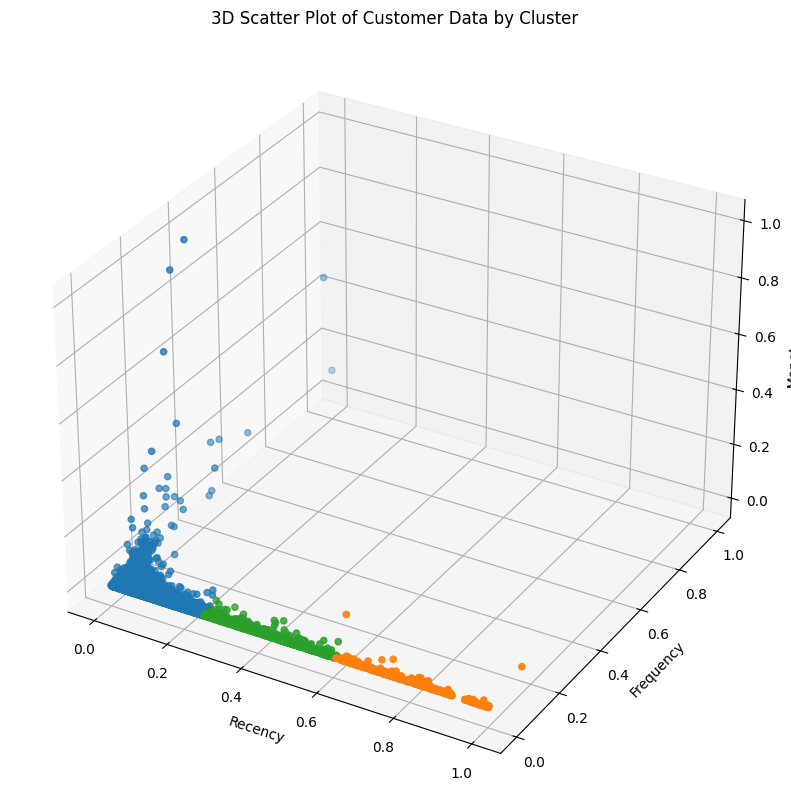

In [104]:
# 3D Scatter Plot 
cluster_colors = {
    0: '#1f77b4',  
    1: '#ff7f0e',  
    2: '#2ca02c',  
}

colors = df_minmax['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(df_minmax['Recency'], 
                     df_minmax['Frequency'], 
                     df_minmax['Monetary'], 
                     c=colors, 
                     marker='o')

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

ax.set_title('3D Scatter Plot of Customer Data by Cluster')

plt.show()

The Elbow Method suggested k=3 and the Silhouette Score was 0.65, giving a strong clustering result. However, the RFM mean values were difficult to interpret due to the influence of extreme outliers.

##### Raw Dataset + RobustScaler

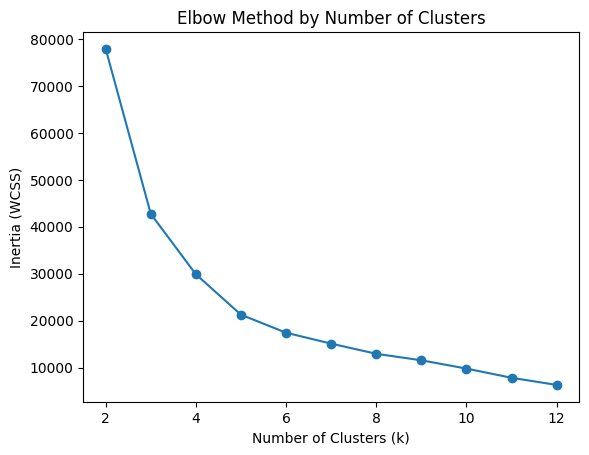

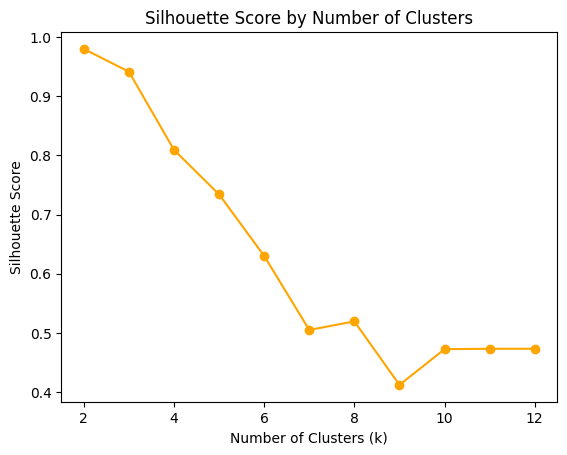

In [105]:
# Creating Elbow method and Silhouette line plot
max_k = 12

inertias = []
silhouette_scores = []
k_values = range(2, max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(df_robust)
    sil_score = silhouette_score(df_robust, cluster_labels)
    silhouette_scores.append(sil_score)
    inertias.append(kmeans.inertia_)

# Elbow Method
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method by Number of Clusters')
plt.show()

# Silhouette Score
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.show()

In [106]:
# Applying model
kmeans = KMeans(n_clusters=4, random_state=42)

# Fitting model
cluster_labels = kmeans.fit_predict(df_robust)

# Checking DB index
db_df_robust = davies_bouldin_score(df_robust, cluster_labels)
print(f"Davies-Bouldin Index: {db_df_robust:.3f}")

# Creating cluster labels
df_robust['Cluster'] = cluster_labels

Davies-Bouldin Index: 0.556


In [107]:
# RFM mean values by cluster
cluster_means_robust = df_robust.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Percentage of customers by cluster
cluster_distribution_robust = df_robust['Cluster'].value_counts(normalize=True) * 100

print('CLUSTER DISTRIBUTION (PERCENTAGE)')
print('='*50)
print(cluster_distribution_robust)
print('='*50)
print('CLUSTER MEAN')
print('='*50)
print(cluster_means_robust)

CLUSTER DISTRIBUTION (PERCENTAGE)
Cluster
0                  96.12
3                   3.44
2                   0.37
1                   0.07
Name: proportion, dtype: float64
CLUSTER MEAN
                     Recency            Frequency             Monetary
Cluster                                                               
0                       0.36                 0.33                 0.34
1                      -0.38                14.33               184.26
2                      -0.34                14.30                54.13
3                      -0.27                 5.26                 9.27


<Axes: xlabel='Cluster'>

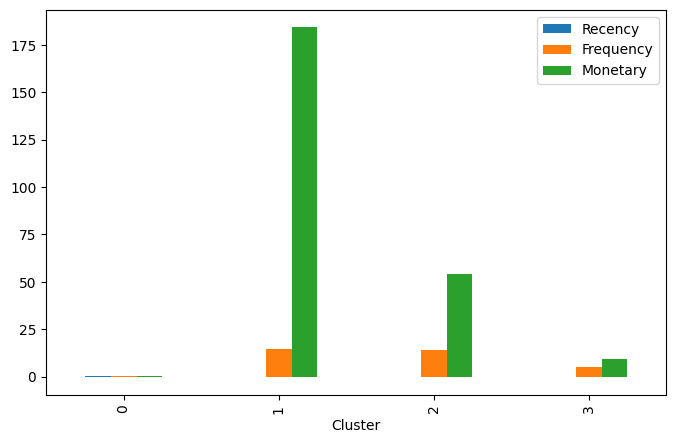

In [108]:
# Mean distribution by cluster 
cluster_means_robust.plot(kind='bar', figsize=(8, 5))

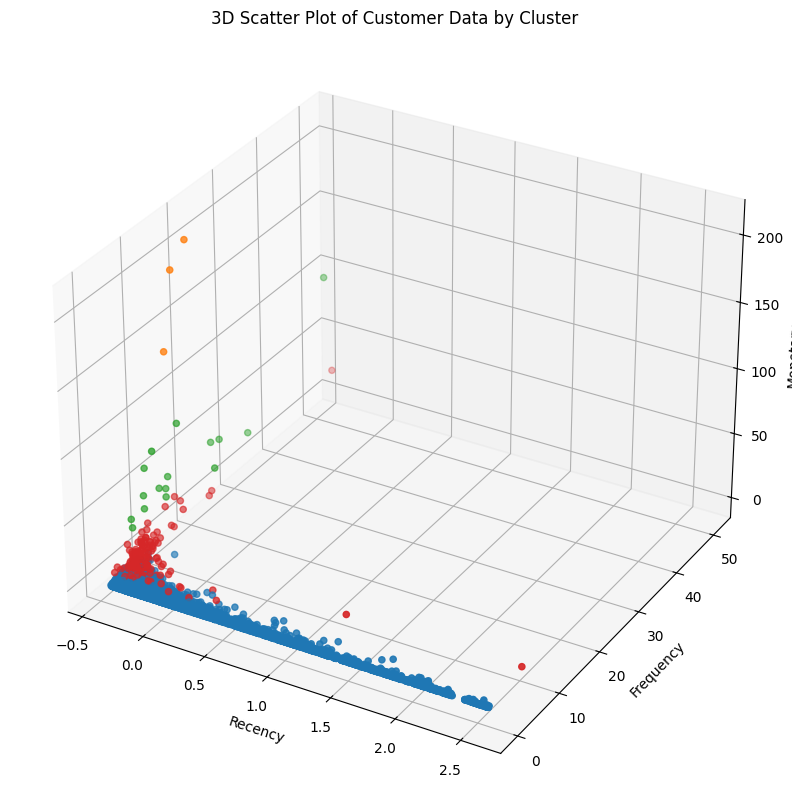

In [109]:
# 3D Scatter Plot 
cluster_colors = {
    0: '#1f77b4',  
    1: '#ff7f0e',  
    2: '#2ca02c', 
    3: '#d62728',
} 

colors = df_robust['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(df_robust['Recency'], 
                     df_robust['Frequency'], 
                     df_robust['Monetary'], 
                     c=colors, 
                     marker='o')

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

ax.set_title('3D Scatter Plot of Customer Data by Cluster')

plt.show()

The Elbow Method suggested k=3 and the Silhouette Score was 0.75, the highest among the tested configurations. However, the cluster distribution was highly unbalanced. k=3 was selected based on the metrics but the configuration was not considered suitable for the final model.

##### IQR + MinMaxScaler (Baseline)

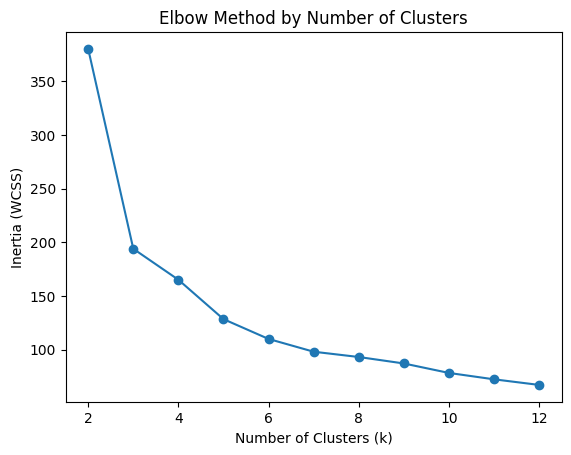

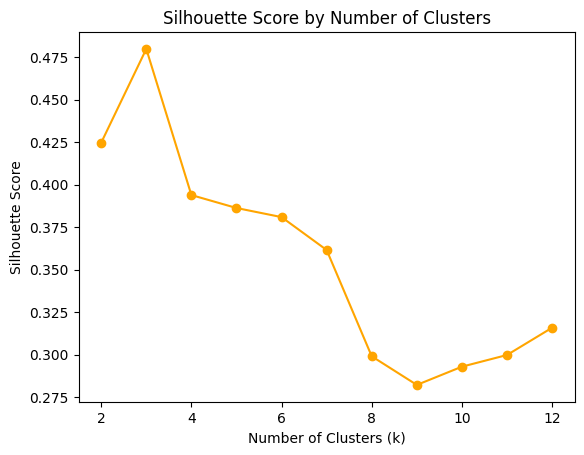

In [110]:
# Creating Elbow method and Silhouette line plot
max_k = 12

inertias = []
silhouette_scores = []
k_values = range(2, max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(IQR_minmax)
    sil_score = silhouette_score(IQR_minmax, cluster_labels)
    silhouette_scores.append(sil_score)
    inertias.append(kmeans.inertia_)

# Elbow Method
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method by Number of Clusters')
plt.show()

# Silhouette Score
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.show()

In [111]:
# Applying model
kmeans = KMeans(n_clusters=3,random_state=42)

# Fitting model
cluster_labels = kmeans.fit_predict(IQR_minmax)

# Checking DB index
db_IQR_minmax = davies_bouldin_score(IQR_minmax, cluster_labels)
print(f"Davies-Bouldin Index: {db_IQR_minmax:.3f}")

# Creating cluster labels
IQR_minmax['Cluster'] = cluster_labels


Davies-Bouldin Index: 0.753


In [112]:
# RFM mean values by cluster
cluster_means_iqr_minmax = IQR_minmax.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Percentage of customers by cluster
cluster_distribution_iqr_minmax = IQR_minmax['Cluster'].value_counts(normalize=True) * 100


print('CLUSTER DISTRIBUTION (PERCENTAGE)')
print('='*50)
print(cluster_distribution_iqr_minmax)
print('='*50)
print('CLUSTER MEAN')
print('='*50)
print(cluster_means_iqr_minmax)

CLUSTER DISTRIBUTION (PERCENTAGE)
Cluster
0                  52.64
1                  25.36
2                  22.00
Name: proportion, dtype: float64
CLUSTER MEAN
                     Recency            Frequency             Monetary
Cluster                                                               
0                       0.14                 0.11                 0.16
1                       0.68                 0.04                 0.11
2                       0.10                 0.49                 0.57


<Axes: xlabel='Cluster'>

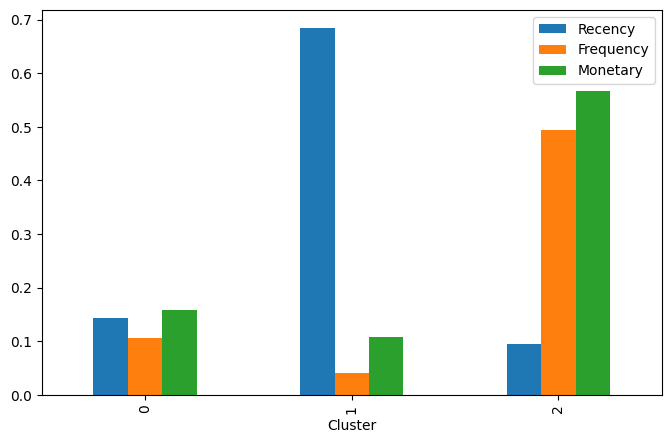

In [113]:
# Mean distribution by cluster 
cluster_means_iqr_minmax.plot(kind='bar', figsize=(8, 5))

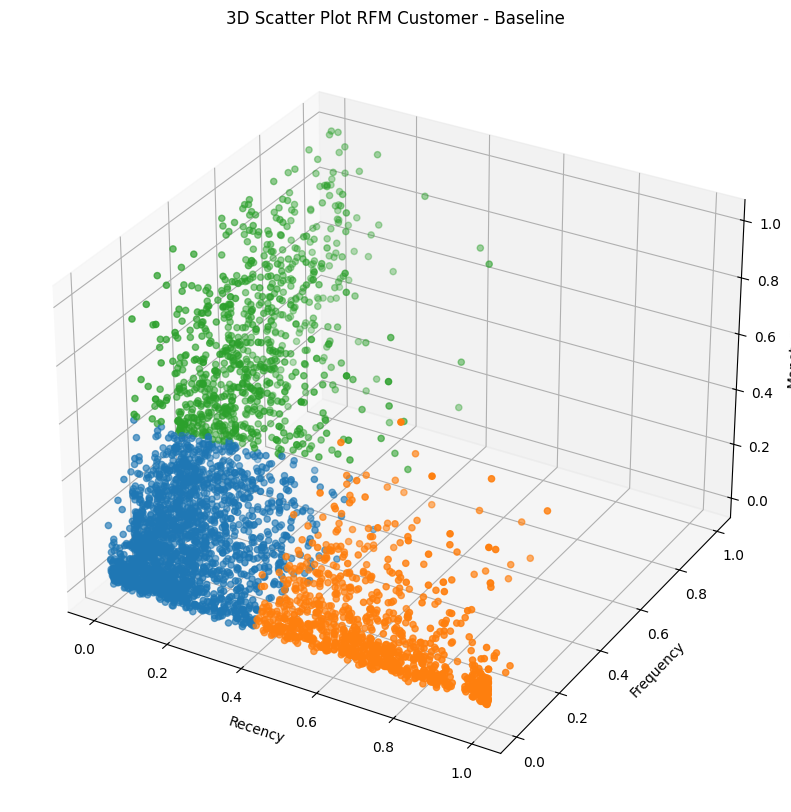

In [114]:
# 3D Scatter Plot 
cluster_colors = {
    0: '#1f77b4', 
    1: '#ff7f0e', 
    2: '#2ca02c',  
} 

colors = IQR_minmax['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(IQR_minmax['Recency'], 
                     IQR_minmax['Frequency'], 
                     IQR_minmax['Monetary'], 
                     c=colors, 
                     marker='o')

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

ax.set_title('3D Scatter Plot RFM Customer - Baseline')

plt.show()

The Elbow Method suggested k=3, with a clear reduction in inertia up to this point. The Silhouette Score was 0.48, which was acceptable. k=3 was selected for this configuration. However, the main concern with the IQR treatment is that it removed a large number of customers, potentially losing important information from high-value and high-frequency customers.

##### IQR + RobustScaler

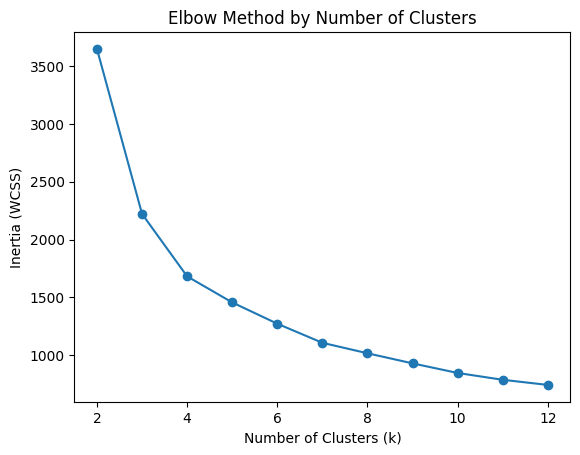

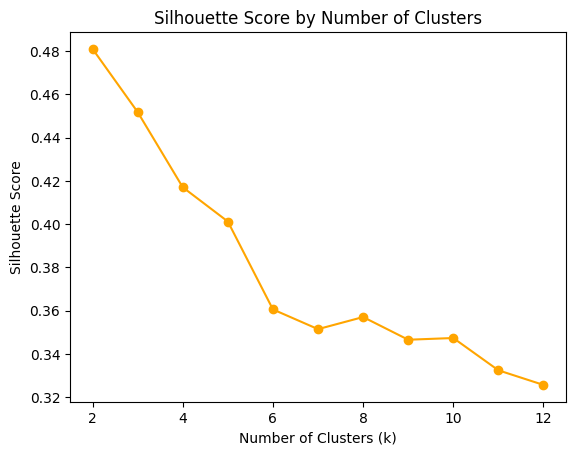

In [115]:
# Creating Elbow method and Silhouette line plot
max_k = 12

inertias = []
silhouette_scores = []
k_values = range(2, max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(IQR_robust)
    sil_score = silhouette_score(IQR_robust, cluster_labels)
    silhouette_scores.append(sil_score)
    inertias.append(kmeans.inertia_)

# Elbow Method
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method by Number of Clusters')
plt.show()

# Silhouette Score
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.show()

In [116]:
# Applying model
kmeans = KMeans(n_clusters=3, random_state=42)

# Fitting model
cluster_labels = kmeans.fit_predict(IQR_robust)

# Checking DB index
db_IQR_robust= davies_bouldin_score(IQR_robust, cluster_labels)
print(f"Davies-Bouldin Index: {db_IQR_robust:.3f}")

# Creating cluster labels
IQR_robust['Cluster'] = cluster_labels

Davies-Bouldin Index: 0.768


In [117]:
# RFM mean values by cluster
cluster_means_iqr_robust = IQR_robust.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Percentage of customers by cluster
cluster_distribution_iqr_robust = IQR_robust['Cluster'].value_counts(normalize=True) * 100

print('CLUSTER DISTRIBUTION (PERCENTAGE)')
print('='*50)
print(cluster_distribution_iqr_robust)
print('='*50)
print('CLUSTER MEAN')
print('='*50)
print(cluster_means_iqr_robust)


CLUSTER DISTRIBUTION (PERCENTAGE)
Cluster
0                  53.03
2                  25.60
1                  21.38
Name: proportion, dtype: float64
CLUSTER MEAN
                     Recency            Frequency             Monetary
Cluster                                                               
0                      -0.05                 0.05                 0.02
1                      -0.15                 1.31                 1.70
2                       1.40                -0.20                -0.21


<Axes: xlabel='Cluster'>

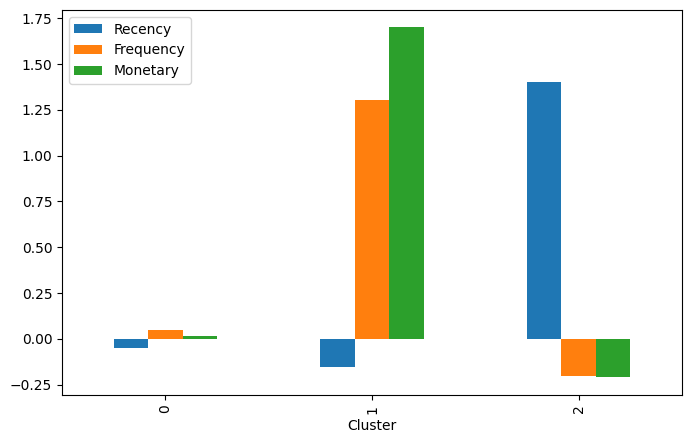

In [118]:
# Mean distribution by cluster
cluster_means_iqr_robust.plot(kind='bar', figsize=(8, 5))

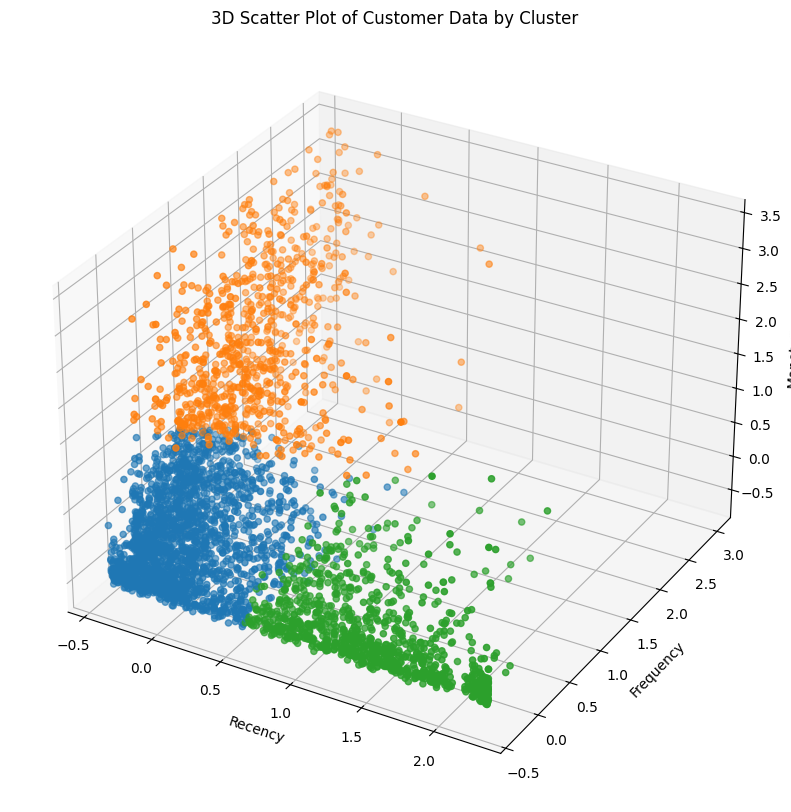

In [119]:
# 3D Scatter Plot
cluster_colors = {
    0: '#1f77b4', 
    1: '#ff7f0e',  
    2: '#2ca02c',  
}

colors = IQR_robust['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(IQR_robust['Recency'], 
                     IQR_robust['Frequency'], 
                     IQR_robust['Monetary'], 
                     c=colors, 
                     marker='o')

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

ax.set_title('3D Scatter Plot of Customer Data by Cluster')

plt.show()

The Elbow Method suggested k=3. The Silhouette Score was 0.45, which was acceptable but worse results than the MinMaxScaler results.

##### Trimmed + MinMaxScaler (Selected)

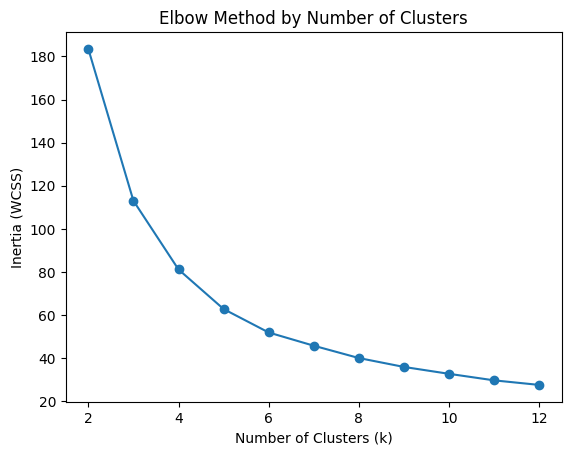

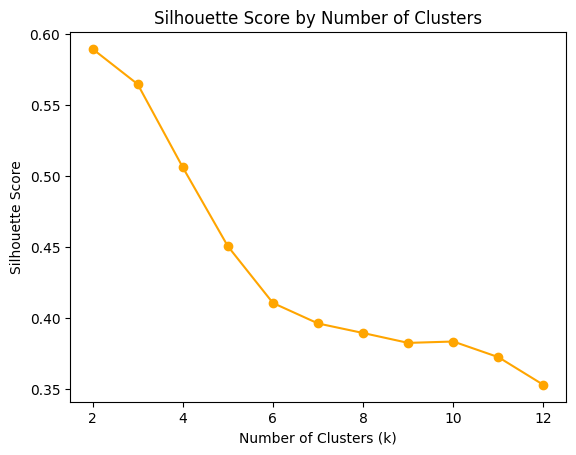

In [120]:
# Creating Elbow method and Silhouette line plot
max_k = 12

inertias = []
silhouette_scores = []
k_values = range(2, max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(trim_minmax)
    sil_score = silhouette_score(trim_minmax, cluster_labels)
    silhouette_scores.append(sil_score)
    inertias.append(kmeans.inertia_) 

# Elbow Method
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method by Number of Clusters')
plt.show()

# Silhouette Score
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.show()

**k = 3 visualization**

In [121]:
# Applying model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Fitting model
cluster_labels = kmeans.fit_predict(trim_minmax)

# Checking DB index
db_trim_minmax = davies_bouldin_score(trim_minmax, cluster_labels)
print(f"Davies-Bouldin Index: {db_trim_minmax:.3f}")

# Creating cluster labels
trim_minmax['Cluster'] = cluster_labels


Davies-Bouldin Index: 0.691


In [122]:
# RFM mean values by cluster
cluster3_means_trim_minmax  = trim_minmax.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Percentage of customers by cluster
cluster3_distribution_trim_minmax  = trim_minmax['Cluster'].value_counts(normalize=True) * 100

print('CLUSTER DISTRIBUTION (PERCENTAGE)')
print('='*50)
print(cluster3_distribution_trim_minmax)
print('='*50)
print('CLUSTER MEAN')
print('='*50)
print(cluster3_means_trim_minmax)


CLUSTER DISTRIBUTION (PERCENTAGE)
Cluster
0                  65.15
1                  24.80
2                  10.05
Name: proportion, dtype: float64
CLUSTER MEAN
                     Recency            Frequency             Monetary
Cluster                                                               
0                       0.12                 0.07                 0.06
1                       0.67                 0.02                 0.03
2                       0.04                 0.41                 0.32


<Axes: xlabel='Cluster'>

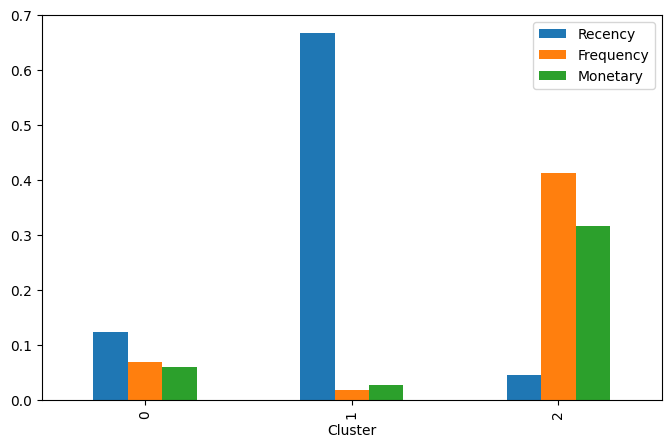

In [123]:
# Mean distribution by cluster
cluster3_means_trim_minmax.plot(kind='bar', figsize=(8, 5))

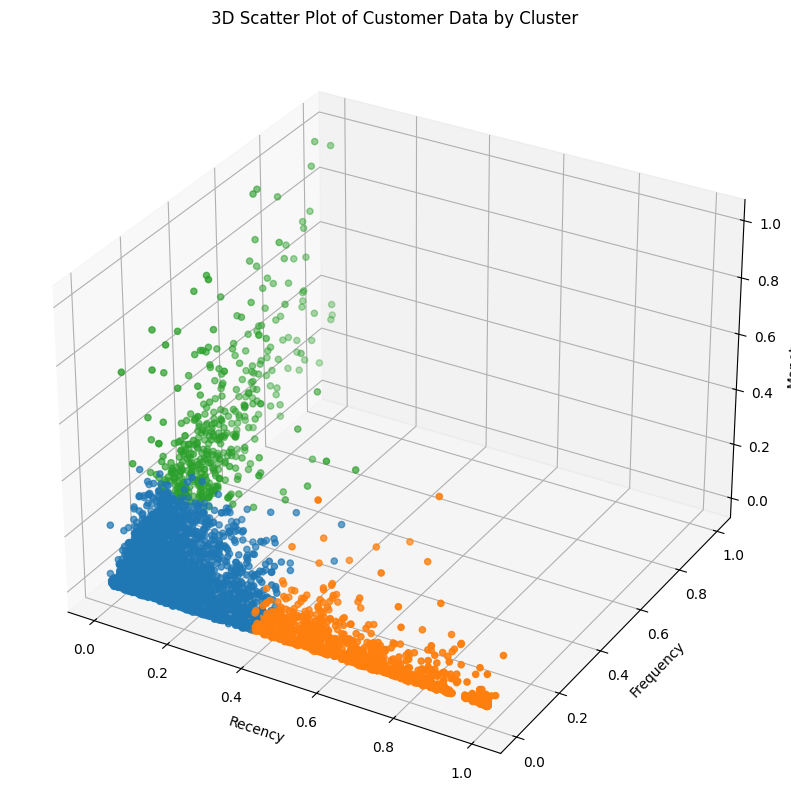

In [124]:
# 3D Scatter Plot
cluster_colors = {
    0: '#1f77b4', 
    1: '#ff7f0e',  
    2: '#2ca02c', 
}

colors = trim_minmax['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(trim_minmax['Recency'], 
                     trim_minmax['Frequency'], 
                     trim_minmax['Monetary'], 
                     c=colors, 
                     marker='o')

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

ax.set_title('3D Scatter Plot of Customer Data by Cluster')

plt.show()

**K = 4 visualization**

In [125]:
trim_minmax = trim_minmax.drop('Cluster', axis=1)

In [126]:
# Applying model with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)

# Fitting model
cluster_labels = kmeans.fit_predict(trim_minmax)

# Checking DB index
db_trim_minmax_4 = davies_bouldin_score(trim_minmax, cluster_labels)
print(f"Davies-Bouldin Index: {db_trim_minmax_4:.3f}")

# Creating cluster labels
trim_minmax['Cluster'] = cluster_labels

Davies-Bouldin Index: 0.681


In [127]:
# RFM mean values by cluster
cluster4_means_trim_minmax  = trim_minmax.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Percentage of customers by cluster
cluster4_distribution_trim_minmax  = trim_minmax['Cluster'].value_counts(normalize=True) * 100

print('CLUSTER DISTRIBUTION (PERCENTAGE)')
print('='*50)
print(cluster4_distribution_trim_minmax)
print('='*50)
print('CLUSTER MEAN')
print('='*50)
print(cluster4_means_trim_minmax)

CLUSTER DISTRIBUTION (PERCENTAGE)
Cluster
0                  58.31
1                  18.03
3                  14.26
2                   9.39
Name: proportion, dtype: float64
CLUSTER MEAN
                     Recency            Frequency             Monetary
Cluster                                                               
0                       0.10                 0.08                 0.06
1                       0.42                 0.04                 0.04
2                       0.04                 0.42                 0.33
3                       0.79                 0.01                 0.02


<Axes: xlabel='Cluster'>

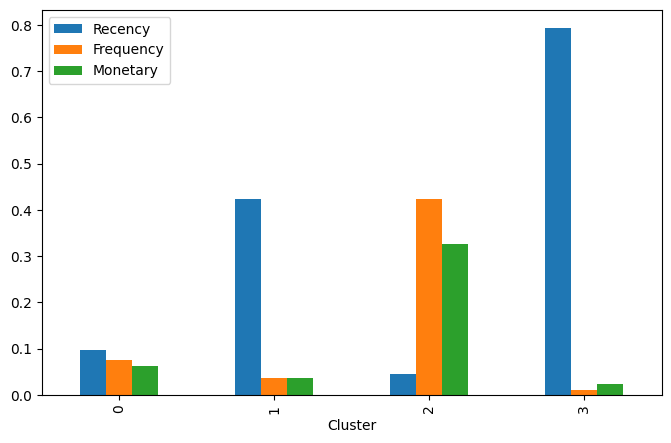

In [128]:
# Mean distribution by cluster
cluster4_means_trim_minmax.plot(kind='bar', figsize=(8, 5))

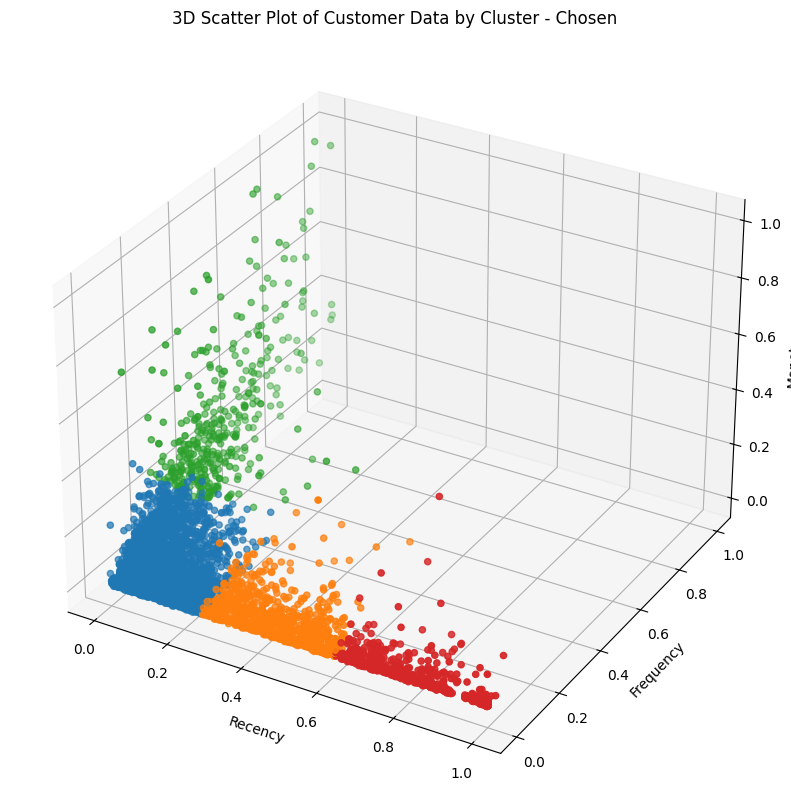

In [129]:
# 3D Scatter Plot
cluster_colors = {
    0: '#1f77b4',
    1: '#ff7f0e',  
    2: '#2ca02c',  
    3: '#d62728'
}  

colors = trim_minmax['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(trim_minmax['Recency'], 
                     trim_minmax['Frequency'], 
                     trim_minmax['Monetary'], 
                     c=colors, 
                     marker='o')

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

ax.set_title('3D Scatter Plot of Customer Data by Cluster - Chosen')

plt.show()

**Why this configuration was selected**

No single metric gave a clear winner across all configurations, so the decision  
was based on a mix of criteria, not just one score.  

IQR MinMax (baseline) and the raw data + MinMax had the most balanced cluster distribution,  
but the lowest metric scores. Robust scaling was already ruled out.  
Trimmed + MinMax retained more customer information than IQR, while still  
having good, balanced metric scores.  

Between k=3 and k=4, both had acceptable Elbow and Silhouette results.  
k=4 was chosen since k=3 alone did not seem to capture enough of the different  
customer behaviours seen in the data, and moving to k=4 kept the overall cluster  
distribution while splitting one cluster into two more specific ones.

##### Trimmed + RobustScaler

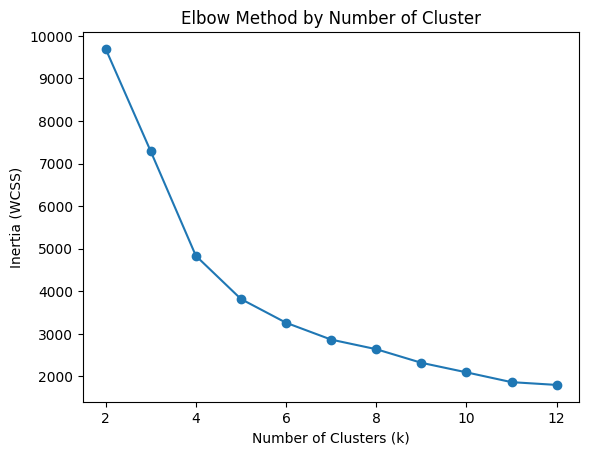

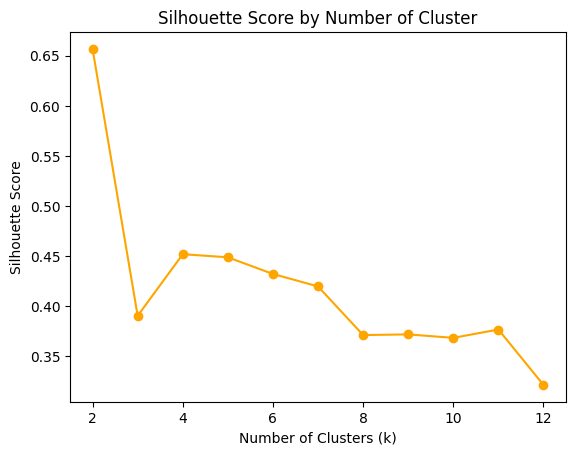

In [130]:
# Creating Elbow method and Silhouette line plot
max_k = 12

inertias = []
silhouette_scores = []
k_values = range(2, max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(trim_robust)
    sil_score = silhouette_score(trim_robust, cluster_labels)
    silhouette_scores.append(sil_score)
    inertias.append(kmeans.inertia_)

# Elbow Method
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method by Number of Cluster')
plt.show()

# Silhouette Score
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Cluster')
plt.show()

In [131]:
# Applying model
kmeans = KMeans(n_clusters=4, random_state=42)

# Fitting model
cluster_labels = kmeans.fit_predict(trim_robust)

# Checking DB index
db_trim_robust = davies_bouldin_score(trim_robust, cluster_labels)
print(f"Davies-Bouldin Index: {db_trim_robust:.3f}")

# Creating cluster labels
trim_robust['Cluster'] = cluster_labels

Davies-Bouldin Index: 0.768


In [132]:
# RFM mean values by cluster
cluster_means_trim_robust = trim_robust.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Percentage of customers by cluster
cluster_distribution_trim_robust = trim_robust['Cluster'].value_counts(normalize=True) * 100

print('CLUSTER DISTRIBUTION (PERCENTAGE)')
print('='*50)
print(cluster_distribution_trim_robust)
print('='*50)
print('CLUSTER MEAN')
print('='*50)
print(cluster_means_trim_robust)

CLUSTER DISTRIBUTION (PERCENTAGE)
Cluster
3                  55.06
1                  23.79
0                  17.49
2                   3.65
Name: proportion, dtype: float64
CLUSTER MEAN
                     Recency            Frequency             Monetary
Cluster                                                               
0                      -0.17                 1.94                 1.88
1                       1.58                -0.20                -0.20
2                      -0.27                 4.93                 6.26
3                      -0.01                 0.15                 0.06


<Axes: xlabel='Cluster'>

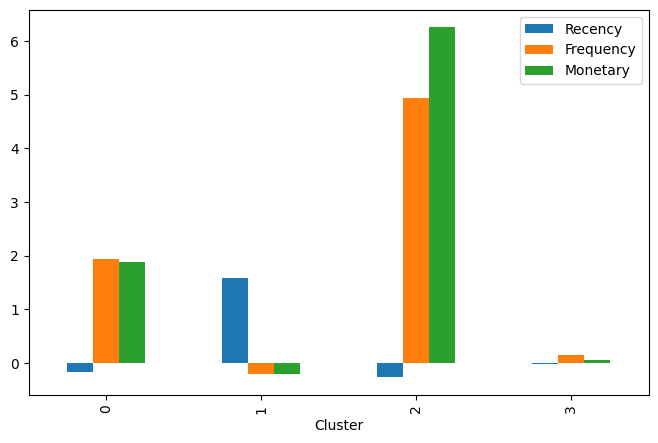

In [133]:
# Mean distribution by cluster
cluster_means_trim_robust.plot(kind='bar', figsize=(8, 5))

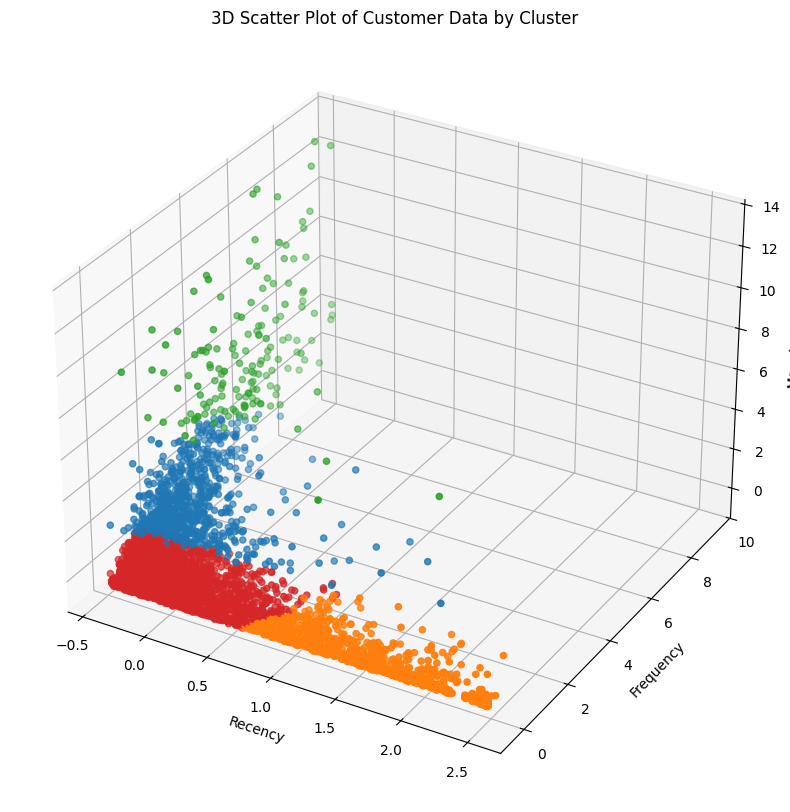

In [134]:
# 3D Scatter Plot
cluster_colors = {
    0: '#1f77b4', 
    1: '#ff7f0e',  
    2: '#2ca02c',  
    3: '#d62728'
}  

colors = trim_robust['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(trim_robust['Recency'], 
                     trim_robust['Frequency'], 
                     trim_robust['Monetary'], 
                     c=colors, 
                     marker='o')

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

ax.set_title('3D Scatter Plot of Customer Data by Cluster')

plt.show()

The Elbow Method suggested k=4 and the Silhouette Score was 0.45. Although k=4 provided an acceptable structure, this configuration performed worse than the MinMaxScaler alternatives.

#### **K-means Improvement**

##### IQR + MinMax (Baseline)

In [135]:
# Dropping Cluster Column
IQR_minmax_improvement = IQR_minmax.drop('Cluster', axis=1)

In [136]:
# Testing K-Means++ with higher n_init and max_iter to check for improvement

# Baseline (IQR + MinMax) - default config
kmeans_default = KMeans(n_clusters=3, random_state=42)
labels_default = kmeans_default.fit_predict(IQR_minmax_improvement)
db_default = davies_bouldin_score(IQR_minmax_improvement, labels_default)
sil_default = silhouette_score(IQR_minmax_improvement, labels_default)

# Baseline (IQR + MinMax) - k-means++ config
kmeans_improved = KMeans(n_clusters=3, random_state=42, n_init=100, init='k-means++', max_iter=500)
labels_improved = kmeans_improved.fit_predict(IQR_minmax_improvement)
db_improved = davies_bouldin_score(IQR_minmax_improvement, labels_improved)
sil_improved = silhouette_score(IQR_minmax_improvement, labels_improved)

print('BASELINE (IQR + MinMax)')
print('='*50)
print(f'Default    - DBI: {db_default:.3f}, Silhouette: {sil_default:.3f}')
print(f'k-means++  - DBI: {db_improved:.3f}, Silhouette: {sil_improved:.3f}')

BASELINE (IQR + MinMax)
Default    - DBI: 0.753, Silhouette: 0.480
k-means++  - DBI: 0.753, Silhouette: 0.480


##### Trimmed + MinMax (Selected)

In [137]:
# Dropping Cluster Column
trim_minmax_improvement = trim_minmax.drop('Cluster', axis=1)

In [138]:
# Testing K-Means++ with higher n_init and max_iter to check for improvement

# Selected model (Trimmed + MinMax) - default config
kmeans_default = KMeans(n_clusters=4, random_state=42)
labels_default = kmeans_default.fit_predict(trim_minmax_improvement)
db_default = davies_bouldin_score(trim_minmax_improvement, labels_default)
sil_default = silhouette_score(trim_minmax_improvement, labels_default)

# Selected model (Trimmed + MinMax) - k-means++ config
kmeans_improved = KMeans(n_clusters=4, random_state=42, n_init=100, init='k-means++', max_iter=500)
labels_improved = kmeans_improved.fit_predict(trim_minmax_improvement)
db_improved = davies_bouldin_score(trim_minmax_improvement, labels_improved)
sil_improved = silhouette_score(trim_minmax_improvement, labels_improved)

print('SELECTED MODEL (Trimmed + MinMax)')
print('='*50)
print(f'Default    - DBI: {db_default:.3f}, Silhouette: {sil_default:.3f}')
print(f'k-means++  - DBI: {db_improved:.3f}, Silhouette: {sil_improved:.3f}')

SELECTED MODEL (Trimmed + MinMax)
Default    - DBI: 0.681, Silhouette: 0.506
k-means++  - DBI: 0.681, Silhouette: 0.506


No meaningful improvement was observed with K-Means++, higher n_init, or increased     
max_iter — DBI and silhouette scores remained consistent with the default configuration.     
The original K-Means setup was retained.

## Preliminary Cluster Results

#### **Cluster assignment**

In [139]:
# Merging CustomerID and Cluster to RFM features
df_clustered = df_trim[['CustomerID', 'Recency', 'Frequency', 'Monetary']].copy()
df_clustered['Cluster'] = trim_minmax['Cluster'].values

In [140]:
# Validating Cluster Assignment
print(df_clustered.shape)
print(df_clustered.isnull().sum())
print(df_clustered['CustomerID'].duplicated().sum())
print(df_clustered['Cluster'].value_counts())

(4270, 5)
CustomerID    0
Recency       0
Frequency     0
Monetary      0
Cluster       0
dtype: int64
0
Cluster
0    2490
1     770
3     609
2     401
Name: count, dtype: int64


In [141]:
# Creating Cluster labels column
labels = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
    3: 'Cluster 3'
}

df_clustered['Cluster_Label'] = df_clustered['Cluster'].map(labels)

#### **Cluster centroids**

In [142]:
# Mean and median RFM values by cluster
mean_rfm = df_clustered.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
median_rfm = df_clustered.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].median()

# Cluster distribution (%)
distribution = (
    df_clustered['Cluster']
    .value_counts(normalize=True)
    .sort_index() * 100
)

print('CLUSTER RFM MEANS')
print('=' * 50)
print(mean_rfm.round(2))

print('=' * 50)
print('CLUSTER RFM MEDIANS')
print('=' * 50)
print(median_rfm.round(2))

print('=' * 50)
print('CLUSTER DISTRIBUTION (%)')
print('=' * 50)
print(distribution.round(2))

CLUSTER RFM MEANS
                     Recency            Frequency             Monetary
Cluster                                                               
0                      36.11                 3.18              1074.41
1                     158.25                 2.04               646.75
2                      16.67                13.30              5640.39
3                     295.80                 1.29               404.04
CLUSTER RFM MEDIANS
                     Recency            Frequency             Monetary
Cluster                                                               
0                      30.00                 3.00               760.75
1                     157.00                 2.00               416.54
2                      10.00                12.00              4762.32
3                     288.00                 1.00               280.55
CLUSTER DISTRIBUTION (%)
Cluster
0                  58.31
1                  18.03
2                   9.39
3 

- Cluster 0 is the largest cluster and shows relatively recent purchasing with moderate frequency and monetary value.
- Cluster 1 has the highest Recency and lowest Frequency/Monetary values, suggesting less recent and less valuable purchasing behaviour.
- Cluster 2 stands out with the lowest Recency, highest Frequency and highest Monetary value among these four clusters, indicating a particularly active and valuable group.
- Cluster 3 has the highest Recency and lowest Frequency and Monetary values, indicating the least engaged group among the four.

The cluster results show clear differences in RFM behaviour across the customer groups. Some clusters are characterised by more recent and frequent purchases,     
while others show lower purchase activity and longer periods since the last purchase. The cluster sizes also vary considerably, providing distinct groups for further analysis.     
These patterns will be explored in greater detail in the next section, where the clusters will be profiled and interpreted.

## Exporting dataset

In [143]:
df_clustered.to_csv('../datasets/02_clustered_customers.csv', index=False)